<a href="https://colab.research.google.com/github/sahanasubbiah24/churn-prediction/blob/main/notebooks/04_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
customer_data = {
    "tenure_months": [
        2, 24, 13, 48, 6, 36, 1, 60, 8, 18,
        42, 3, 27, 54, 10, 31, 5, 45, 22, 12
    ],
    "monthly_charge": [
        29.99, 75.50, 54.25, 89.99, 45.00,
        66.75, 20.00, 99.50, 82.00, 58.25,
        72.50, 95.00, 61.00, 85.50, 43.25,
        68.00, 35.00, 91.00, 56.50, 47.00
    ],
    "contract_type": [
        "Month-to-month", "One year", "Month-to-month",
        "Two year", "Month-to-month", "One year",
        "Month-to-month", "Two year", "Month-to-month",
        "One year", "Two year", "Month-to-month",
        "One year", "Two year", "Month-to-month",
        "One year", "Month-to-month", "Two year",
        "One year", "Month-to-month"
    ],
    "churn": [
        "Yes", "No", "Yes", "No", "Yes",
        "No", "Yes", "No", "Yes", "No",
        "No", "Yes", "No", "No", "Yes",
        "No", "Yes", "No", "No", "Yes"
    ],
    "support_calls": [
        5, 1, 3, 0, 4, 1, 6, 0, 5, 2,
        1, 7, 2, 0, 4, 1, 5, 0, 2, 3
    ]
}

customers = pd.DataFrame(customer_data)

customers.head()

,tenure_months,monthly_charge,contract_type,churn,support_calls
0,2,29.99,Month-to-month,Yes,5
1,24,75.50,One year,No,1
2,13,54.25,Month-to-month,Yes,3
3,48,89.99,Two year,No,0
4,6,45.00,Month-to-month,Yes,4


In [ ]:
customers["churn_numeric"] = customers[
    "churn"
].map({
    "No": 0,
    "Yes": 1
})

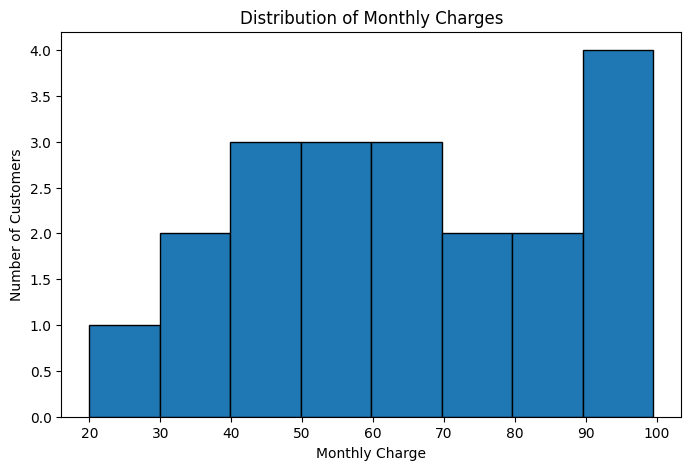

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    customers["monthly_charge"],
    bins=8,
    edgecolor="black"
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charge")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
churn_by_contract = customers.groupby(
    "contract_type"
)["churn_numeric"].mean() * 100

churn_by_contract

,churn_numeric
contract_type,
Month-to-month,100.0
One year,0.0
Two year,0.0


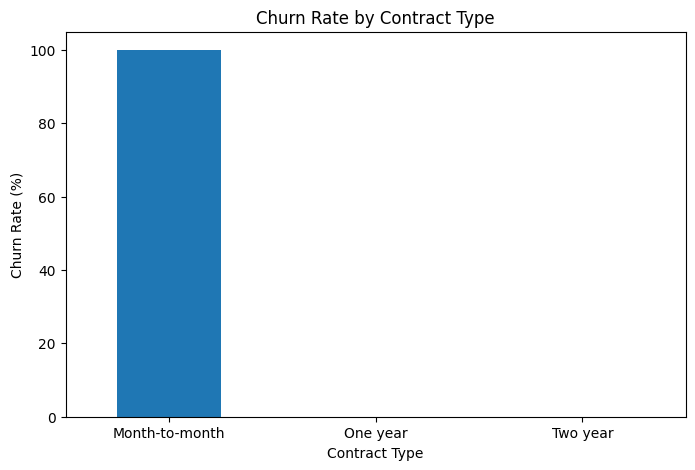

In [ ]:
plt.figure(figsize=(8, 5))

churn_by_contract.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

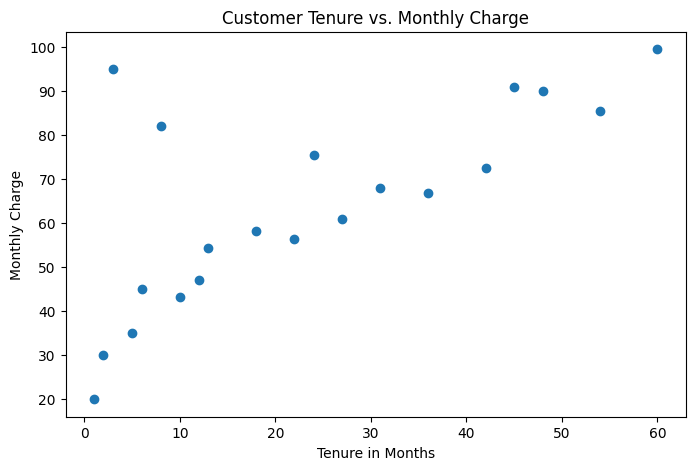

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    customers["tenure_months"],
    customers["monthly_charge"]
)

plt.title("Customer Tenure vs. Monthly Charge")
plt.xlabel("Tenure in Months")
plt.ylabel("Monthly Charge")
plt.show()

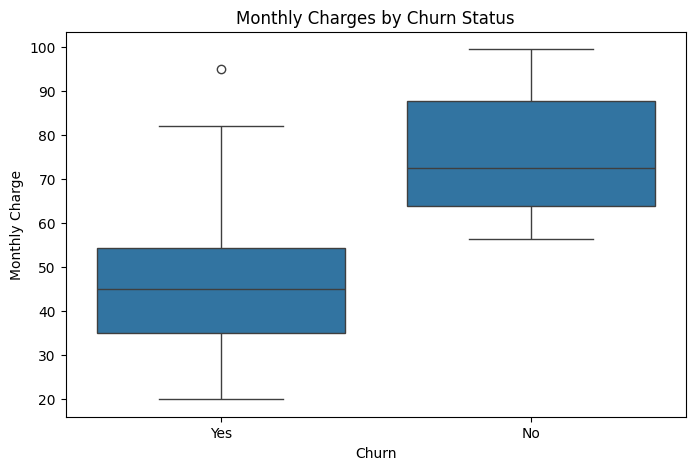

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=customers,
    x="churn",
    y="monthly_charge"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charge")
plt.show()

In [ ]:
numeric_columns = customers[
    [
        "tenure_months",
        "monthly_charge",
        "support_calls",
        "churn_numeric"
    ]
]

In [ ]:
correlation_matrix = numeric_columns.corr()

correlation_matrix

,tenure_months,monthly_charge,support_calls,churn_numeric
tenure_months,1.000000,0.703363,-0.910418,-0.829047
monthly_charge,0.703363,1.000000,-0.535762,-0.555772
support_calls,-0.910418,-0.535762,1.000000,0.877339
churn_numeric,-0.829047,-0.555772,0.877339,1.000000


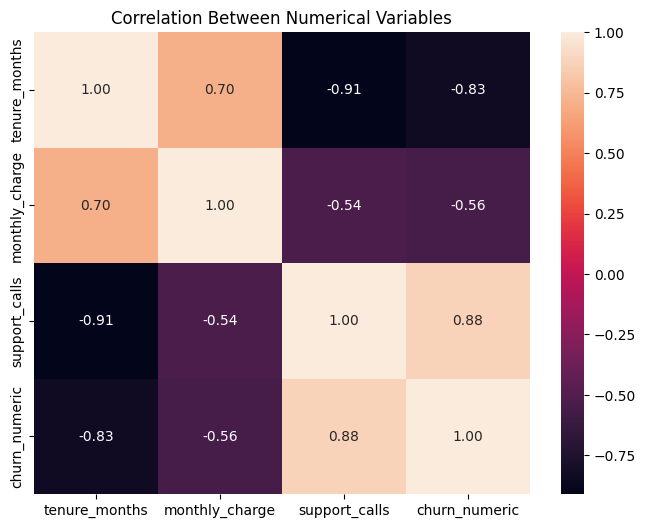

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")
plt.show()